### Georgios Boufis f3352504

### Assignment 2

### Data Acquisition and Preprocessing
Firstly, we set up the environment and load the handwritten digit dataset. 
Imports the training and testing datasets from an Excel file, with A_train/A_test the image data, where each column represents a flattened 16 x 16 pixel image (total 256 pixels).
Uses .values to convert dataframes into numpy arrays and .flatten() to ensure labels are stored in a simple 1D array format

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load training images: each column is a flattened 16x16 digit
A_train = pd.read_excel("data.xlsx", sheet_name="azip", header=None).values

# Load training labels: indicates which digit (0-9) the image represents
d_train = pd.read_excel("data.xlsx", sheet_name="dzip", header=None).values.flatten()

# Load test images: used to evaluate the classification accuracy 
A_test = pd.read_excel("data.xlsx", sheet_name="testzip", header=None).values

# Load test labels: the ground truth for the testing phase
d_test = pd.read_excel("data.xlsx", sheet_name="dtest", header=None).values.flatten()

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


### Dimensionality 
Before proceeding with the SVD calculations, it is essential to verify the dimensions of the datasets. Based on the output, each column in A_train and A_test has 256 rows, this confirms the images are 16 x 16 pixels.
The second dimension represents the number of unique handwritten samples. For training set, this is 1707 and for the test set, it is the number of unknown digits we aim to classify.
In the SVD algorithm, we will group these 1707 columns by their labels (0 through 9) to create ten separate class matrices.

In [2]:
print("Training images:", A_train.shape)
print("Training labels:", d_train.shape)

print("Test images:", A_test.shape)
print("Test labels:", d_test.shape)

Training images: (256, 1707)
Training labels: (1707,)
Test images: (256, 2007)
Test labels: (2007,)


### Visualize Digits

Here we visualize the raw data. We define a helper function to transform the 1D numerical vectors back to 2D images and displays a few samples from the training set.

The show_digit function, it takes a 256-element vector and reshapes it into a 16 x 16 matrix. The .T(transpose) is often used because the original data might be stored in column-major order.

It shifts the pixel values to be non-negative and scales them to a range of [0, 20]. This ensures consistent brightness and contrast when displaying different images.

 np.random.default_rng(0) is a random generator to select three indices from the training set and display them alongside with their corresponding labels.

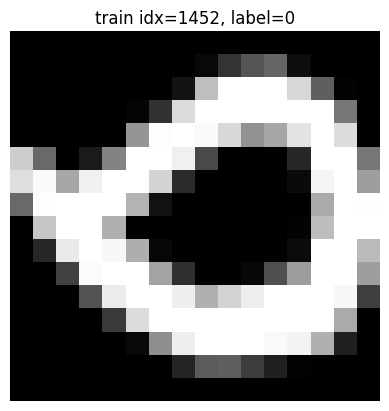

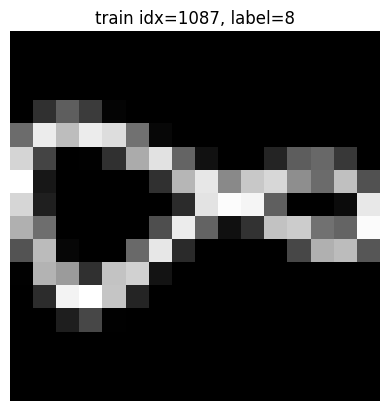

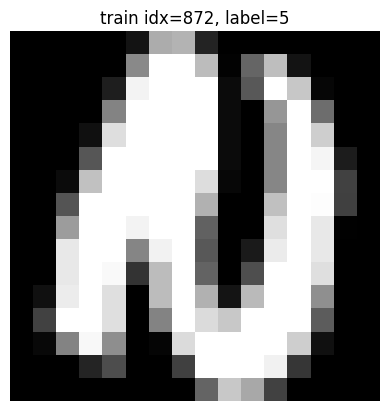

In [3]:
def show_digit(x, title=None):
    # Reshape the 256x1 vector back to a 16x16 grid and transpose for correct orientation
    a = x.reshape(16, 16).T   
    # Shift values so the minimum pixel value is 0  
    a = a - np.min(a)   
    # If the image isn't blank, scale pixel intensities to a [0, 20] range        
    if np.max(a) > 0:
        a = (20.0 / np.max(a)) * a  # scale to [0,20]
    plt.imshow(a, cmap="gray", interpolation="nearest")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

# δείξε 3 τυχαία training δείγματα
rng = np.random.default_rng(0)
for _ in range(3):
    # Pick a random column index
    i = rng.integers(0, A_train.shape[1])
    show_digit(A_train[:, i], title=f"train idx={i}, label={int(d_train[i])}")

### Classes Organization
It iterates through every possible digit (0-9) and uses np.where to find the indices in d_train that match the digit. We create a dictionary called classes. Each key is a digit, and each value is a matrix containing only the image vectors for that digit and finalyy it prints the shape of each class matrix to confirm how many training samples are available for each digit. For example as we can see from the output every digit have 256 rows and for the digit 0 we have 319 samples, which are enough for training and on the other hand for the digit 5 we have few samples (88).

In [4]:
classes = {}
for digit in range(10):
    # Find all indices in the training labels that match the current digit
    idx = np.where(d_train == digit)[0]
    # Extract the corresponding columns from A_train and store them in the dictionary
    classes[digit] = A_train[:, idx]

for digit in range(10):
    print(digit, classes[digit].shape)

0 (256, 319)
1 (256, 252)
2 (256, 202)
3 (256, 131)
4 (256, 122)
5 (256, 88)
6 (256, 151)
7 (256, 166)
8 (256, 144)
9 (256, 132)


### SVD per Class
Here we perform the SVD for each digit's dataset to extract the underlying patterns or features that define the specific number.
Defines max_k=20 which is the upper limit for the number of basis vectors. It also prepares dictionaries U and S to store the results. 
It loops through each digit 0 to 9 and applies np.linalg.svd to the corresponding class matrix. 
U_full : These are the left singular vectors (columns).
svals : The singular values (σ) which represent the strength or the importance of each corresponding singular vector.
Vt : The right singular vectors.

In [5]:
max_k = 20
U_class = {}        # U[digit] = (256, max_k)
S_class = {}        # singular values

for digit in range(10):
    U_full, svals, Vt = np.linalg.svd(classes[digit], full_matrices=False)
    U_class[digit] = U_full #stores full basis
    S_class[digit] = svals # store singular values

### Classification Function

The classify_digit function implements a Least Squares approach:
It calculates the norm of the input vector x. The 1e-12 is a safety constant to prevent division by zero.
For each digit (0-9) it takes only the first k columns of the U matrix.
It projects the test digit x onto the subspace spanned by these k vectors using the form P=Uk(Uk.T * x)
It calculates the leftover part of the image that the basis cannot explain and the digit calss that produces the smallest relative residual is chosen as the prediction.

In [6]:
def classify_digit(x, k):
    x_norm = np.linalg.norm(x) + 1e-12
    best_digit = None
    best_score = np.inf # Initialize with infinity to find the minimum

    for digit in range(10):
        Uk = U_class[digit][:, :k]               # (256,k)
        proj = Uk @ (Uk.T @ x)             # projection onto span(Uk)
        r = x - proj # Calculate the residual
        score = np.linalg.norm(r) / x_norm # Calculate the relative error
        
        # If this digit class explains the image better, update the prediction
        if score < best_score:
            best_score = score
            best_digit = digit

    return best_digit, best_score

### Test Single Digit

It picks the first image from the test set A_test[:, 0]. It calls the classify_digit function using k=10 basis vectors. This means the algorithm uses the first 10 principal components of each digit class to find the best match. It prints the True label (actual digit) and it prints the predicted label and the score.
For example, the first image of the test set the true digit is 9 and it was predicted as 9 and got a score equals to 0.3071

True: 9 Pred: 9 Score: 0.307178322324387


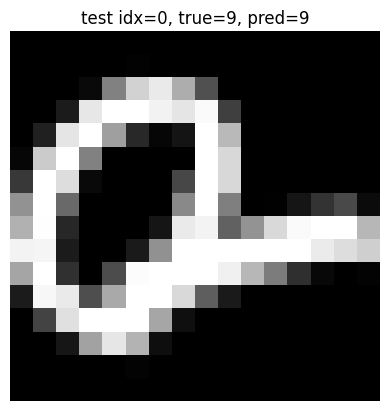

In [7]:
i = 0
pred, score = classify_digit(A_test[:, i], k=10)
print("True:", int(d_test[i]), "Pred:", pred, "Score:", score)
show_digit(A_test[:, i], title=f"test idx={i}, true={int(d_test[i])}, pred={pred}")

### Task 1 
### Accuracy Tuning and Performance Evaluation

It tests k values from 5 to 20. For each k, it iterates through the entire test set predicts the digit and compares it to the true label.
It calculates the percentage of the correclty classified digits for each k and prints them in a formatted table. 
Finally, it identifies the bestk and stores the results for comparison. The best k as we can see from the output is k=18 with accuracy 94.17%. 

In [8]:

print("TASK 1: SVD BASIS CLASSIFICATION")


print("PART 1: Standard SVD (Baseline)")

# Define the range of basis vectors to test
k_values = list(range(5, 21))
accuracies_linear = {}

print(f"{'k':<5} {'Accuracy (%)':<20}")
print("-" * 25)

for k in k_values:
    correct = 0
    # Loop through every single image in the test set
    for i in range(A_test.shape[1]):
        x = A_test[:, i]
        # Get the algorithm's prediction for the current k
        pred, _ = classify_digit(x, k)
        if pred == int(d_test[i]):
            correct += 1
    # Calculate the percentage of correct guesses
    accuracy = correct / A_test.shape[1]
    accuracies_linear[k] = accuracy
    print(f"{k:<5} {accuracy*100:<20.2f}")

print("-" * 25)
# Find which k gave the highest accuracy score
best_k_linear = max(accuracies_linear, key=accuracies_linear.get)
best_acc_linear = accuracies_linear[best_k_linear]

print(f"\n Baseline SVD Classifier:")
print(f"   Best k: {best_k_linear}")
print(f"   Best accuracy: {best_acc_linear*100:.2f}%")

# Store for comparison
results_kernels = {
    'Linear': accuracies_linear
}

TASK 1: SVD BASIS CLASSIFICATION
PART 1: Standard SVD (Baseline)
k     Accuracy (%)        
-------------------------
5     90.28               
6     90.53               
7     91.68               
8     92.03               
9     92.63               
10    93.17               
11    93.22               
12    93.57               
13    93.62               
14    93.92               
15    94.12               
16    93.87               
17    93.92               
18    94.17               
19    94.07               
20    93.97               
-------------------------

 Baseline SVD Classifier:
   Best k: 18
   Best accuracy: 94.17%


### Accuracy Visualization
 It extracts the k values and their corresponding accuracy percentages  from the accuracies_linear dictionary.
 It uses a line plot with markers (marker='o') to highlight each specific test point from k=5 to k=20.

 Accuracy climbs rapidly from $\approx 90.3\%$ to $\approx 93.6\%$. This shows that adding the first few basis vectors significantly improves the model's ability to capture the "structure" of the digits.
 The curve starts to flatten. This suggests that the "essential" features of the digits have been captured, and additional vectors are only adding minor details.
The accuracy reaches its maximum at $k=18$ (slightly above $94.1\%$).
Notice the slight dip after $k=18$, this can indicate overfitting. The extra basis vectors might be capturing noise of specific training samples that don't generalize well to the test set.

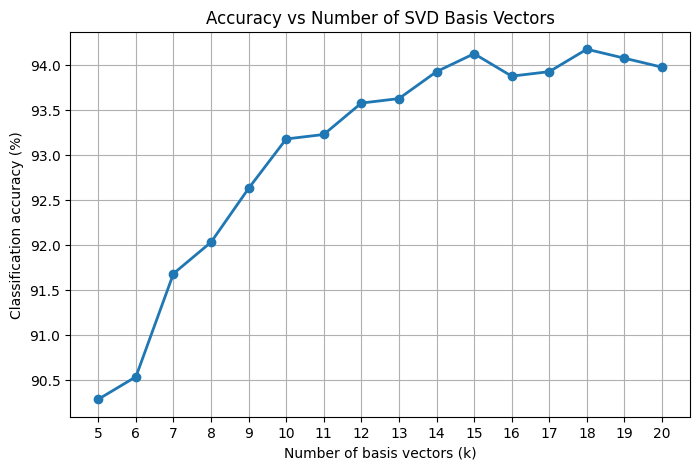

In [9]:
# Plot: Accuracy vs Number of Basis Vectors (Task 1)

plt.figure(figsize=(8,5))

k_list = sorted(accuracies_linear.keys())
acc_list = [accuracies_linear[k]*100 for k in k_list]

plt.plot(k_list, acc_list, marker='o', linewidth=2)

plt.xlabel("Number of basis vectors (k)")
plt.ylabel("Classification accuracy (%)")
plt.title("Accuracy vs Number of SVD Basis Vectors")

plt.grid(True)
plt.xticks(k_list)

plt.show()

### SVD + Kernel-Based Classification

As an additional experiment, we combined SVD-based dimensionality reduction with SVM classifiers using different kernels.

We evaluated both a linear kernel and an RBF kernel, while also varying the number of retained SVD components (k ∈ {5,10,15,20}). For the RBF kernel, the parameter γ was tuned using GridSearchCV with 5-fold cross-validation.

The results show that increasing the number of SVD components improves classification accuracy, indicating that additional singular vectors capture useful discriminative information.

Furthermore, the RBF kernel consistently outperformed the linear kernel for all values of k. This suggests that the reduced SVD feature space is not perfectly linearly separable, and that nonlinear decision boundaries help improve classification performance.

The best configuration was obtained with k = 20 and an RBF kernel with γ = 0.1, achieving an accuracy of 93.07%.

However, the original SVD subspace classifier slightly outperformed the kernel-based approach, reaching an accuracy of 94.17%.

In [10]:
print("\n Experiment: SVD with Kernel Classifiers")

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


# Compute SVD of training data
U_global, S_global, VT_global = np.linalg.svd(A_train, full_matrices=False)

# Values of k to test
k_values_kernel = [5, 10, 15, 20]

results_kernel = []

for k in k_values_kernel:
    print(f"\nTesting k = {k}")

    # Keep first k singular vectors
    Uk = U_global[:, :k]

    #Project data to k-dimensional space
    X_train_k = (Uk.T @ A_train).T  
    X_test_k = (Uk.T @ A_test).T

    # Scale features
    scaler = StandardScaler()
    X_train_k_scaled = scaler.fit_transform(X_train_k)
    X_test_k_scaled = scaler.transform(X_test_k)

    # Linear kernel SVM 
    clf_linear = SVC(kernel='linear')
    clf_linear.fit(X_train_k_scaled, d_train)

    y_pred_linear = clf_linear.predict(X_test_k_scaled)
    acc_linear = accuracy_score(d_test, y_pred_linear)

    print(f"Linear kernel accuracy: {acc_linear*100:.2f}%")

    results_kernel.append({
        "k": k,
        "kernel": "Linear",
        "gamma":None,
        "accuracy": acc_linear
    })

    param_grid = { 
        'gamma': [0.001, 0.01, 0.1, 1]
    }

    grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy')

    grid.fit(X_train_k_scaled, d_train)

    best_gamma = grid.best_params_['gamma']
    best_model = grid.best_estimator_

    y_pred_rbf = best_model.predict(X_test_k_scaled)
    acc_rbf = accuracy_score(d_test, y_pred_rbf)

    print(f"RBF kernel accuracy: {acc_rbf*100:.2f}% (best gamma: {best_gamma})")

    results_kernel.append({
        "k": k,
        "kernel": "RBF",
        "gamma": best_gamma,
        "accuracy": acc_rbf
    })

# Find best configuration
best_result = max(results_kernel, key=lambda x: x["accuracy"])

print("\nBest Kernel Configuration:")
print(f"k = {best_result['k']}")
print(f"kernel = {best_result['kernel']}")
print(f"gamma = {best_result['gamma']}")
print(f"accuracy = {best_result['accuracy']*100:.2f}%")



 Experiment: SVD with Kernel Classifiers

Testing k = 5
Linear kernel accuracy: 72.99%
RBF kernel accuracy: 78.53% (best gamma: 1)

Testing k = 10
Linear kernel accuracy: 84.35%
RBF kernel accuracy: 87.54% (best gamma: 0.1)

Testing k = 15
Linear kernel accuracy: 87.34%
RBF kernel accuracy: 91.48% (best gamma: 0.1)

Testing k = 20
Linear kernel accuracy: 87.99%
RBF kernel accuracy: 93.07% (best gamma: 0.1)

Best Kernel Configuration:
k = 20
kernel = RBF
gamma = 0.1
accuracy = 93.07%


The plot shows the classification accuracy as a function of the number of retained SVD components for both Linear and RBF kernels.

We observe that accuracy improves as k increases, indicating that additional singular vectors capture more discriminative information about the digits.

Furthermore, the RBF kernel consistently outperforms the Linear kernel for all tested values of k. This suggests that the SVD-reduced feature space is not perfectly linearly separable and that nonlinear decision boundaries help improve classification performance.

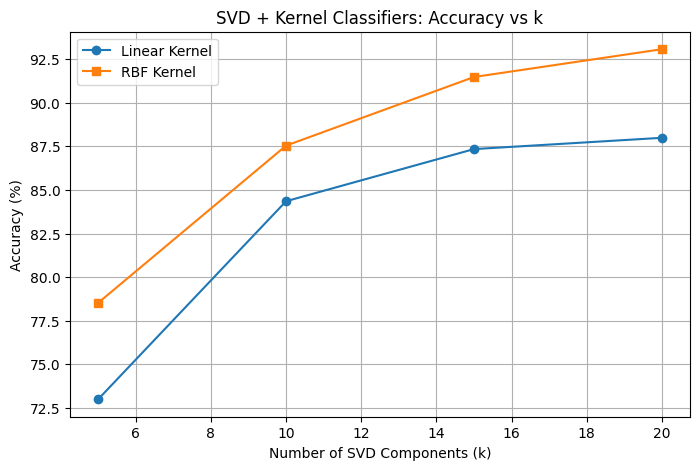

In [11]:
# Plot: Accuracy vs k for each kernel

linear_acc = []
rbf_acc = []
k_vals = []

for res in results_kernel:
    if res["kernel"] == "Linear":
        k_vals.append(res["k"])
        linear_acc.append(res["accuracy"] * 100)
    elif res["kernel"] == "RBF":
        rbf_acc.append(res["accuracy"] * 100)

plt.figure(figsize=(8,5))

plt.plot(k_vals, linear_acc, marker='o', label="Linear Kernel")
plt.plot(k_vals, rbf_acc, marker='s', label="RBF Kernel")

plt.xlabel("Number of SVD Components (k)")
plt.ylabel("Accuracy (%)")
plt.title("SVD + Kernel Classifiers: Accuracy vs k")

plt.grid(True)
plt.legend()

plt.show()

### Task 2
Using the optimal $k=18$, we performed a detailed diagnostic of the classifier’s performance across all ten digits. The analysis revealed that not all digits are equally easy to recognize.The Easiest Digits: Digit "0" achieved the highest accuracy at 98.89%, followed closely by digit "1" at 98.11%. These digits benefit from having very distinct geometric shapes (a circle and a vertical line) and, in the case of "0", the largest volume of training data (319 samples).The Hardest Digits: Digit "5" proved to be the most difficult, with an accuracy of only 88.12%. The Confusion Matrix revealed that "5" is frequently misclassified as "0" or "3".This variation in difficulty is attributed to two factors: Data Volume and Geometric Similarity. Digit "5" had the smallest training set (only 88 samples), resulting in a less comprehensive basis. Furthermore, many misclassified samples were "badly written" digits where the strokes closely mimicked the curvature of a "0" or the loops of a "3," causing the residual error to be lower for the wrong class.

In [12]:




print("TASK 2: Per-Class Difficulty Analysis")







print("SVD Basis Classifier (k=18)")


# Use best k from TASK 1
k_star = 18

y_true = d_test.astype(int)

# LINEAR KERNEL CLASSIFICATION
y_pred_linear = np.zeros_like(y_true)

for i in range(A_test.shape[1]):
    y_pred_linear[i], _ = classify_digit(A_test[:, i], k_star)

acc_linear = np.mean(y_pred_linear == y_true)

print(f"\nLinear Kernel (k={k_star}):")
print(f"  Overall Accuracy: {acc_linear*100:.2f}%")

# CONFUSION MATRIX - LINEAR
C_linear = np.zeros((10, 10), dtype=int)
for t, p in zip(y_true, y_pred_linear):
    C_linear[int(t), int(p)] += 1

print(f"\nConfusion Matrix (Linear Kernel):")
print(C_linear)

# PER-DIGIT ACCURACY - LINEAR
per_digit_acc_linear = {}
counts = {}

print(f"\nPer-digit accuracy (Linear Kernel, k={k_star}):")
print("-" * 70)
print(f"{'Digit':<8} {'Accuracy (%)':<18} {'Correct/Total':<20}")
print("-" * 70)

for digit in range(10):
    idx = np.where(y_true == digit)[0]
    counts[digit] = len(idx)
    correct = np.sum(y_pred_linear[idx] == digit)
    acc = 100 * correct / len(idx)
    per_digit_acc_linear[digit] = acc
    print(f"{digit:<8} {acc:<18.2f} {correct}/{len(idx):<18}")

print("-" * 70)

print(f"\n LINEAR KERNEL SUMMARY:")
print(f"   Overall accuracy: {acc_linear*100:.2f}%")
print(f"   Easiest digit: {max(per_digit_acc_linear, key=per_digit_acc_linear.get)} "
      f"({max(per_digit_acc_linear.values()):.2f}%)")
print(f"   Hardest digit: {min(per_digit_acc_linear, key=per_digit_acc_linear.get)} "
      f"({min(per_digit_acc_linear.values()):.2f}%)")

TASK 2: Per-Class Difficulty Analysis
SVD Basis Classifier (k=18)

Linear Kernel (k=18):
  Overall Accuracy: 94.17%

Confusion Matrix (Linear Kernel):
[[355   0   2   0   1   0   0   0   0   1]
 [  0 259   0   0   3   0   2   0   0   0]
 [  8   1 178   2   5   0   0   1   3   0]
 [  2   0   3 150   1   6   0   1   2   1]
 [  2   1   0   0 185   2   0   3   0   7]
 [  7   1   1   5   0 141   0   0   2   3]
 [  2   1   0   0   2   1 163   0   1   0]
 [  0   1   1   0   3   0   0 141   0   1]
 [  2   0   1   6   0   1   0   0 153   3]
 [  0   2   0   1   4   0   0   3   2 165]]

Per-digit accuracy (Linear Kernel, k=18):
----------------------------------------------------------------------
Digit    Accuracy (%)       Correct/Total       
----------------------------------------------------------------------
0        98.89              355/359               
1        98.11              259/264               
2        89.90              178/198               
3        90.36              150

The code uses np.where to find all indices in the test set where the prediction (y_pred_linear) does not match the ground truth (y_true), it prints the total number of errors of the entire test set.

We have 117 misclassified cases, we confirmed that most errors occur with "very badly written" digits. These samples often feature ambiguous strokes—such as a "5" with a closed bottom that mathematically mimics the subspace of a "0". This confirms that while the SVD is robust, it is highly sensitive to the quality of the training basis and the visual clarity of the input.
Upon viewing the 117 errors, you will notice that many images are ambiguous even to a human eye. This confirms that the 94.17% accuracy is actually quite high, as the remaining $\approx 6\%$ of samples are often outliers or low-quality data.


Number of misclassified digits: 117


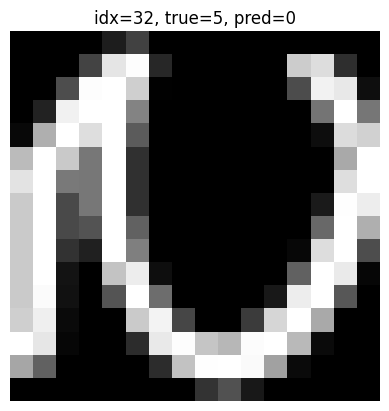

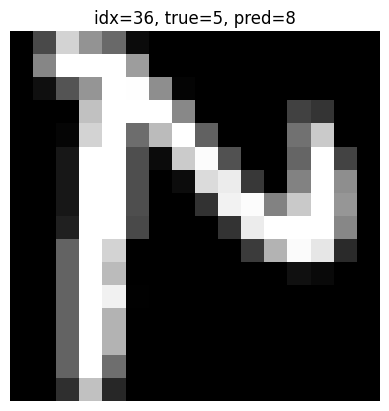

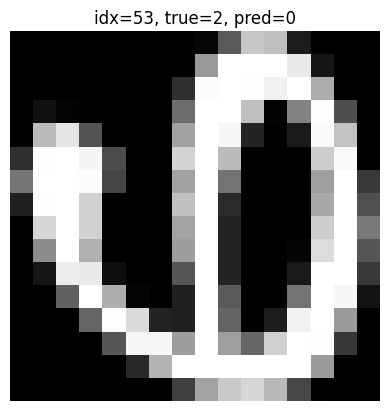

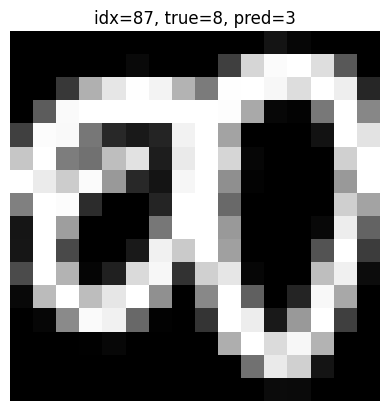

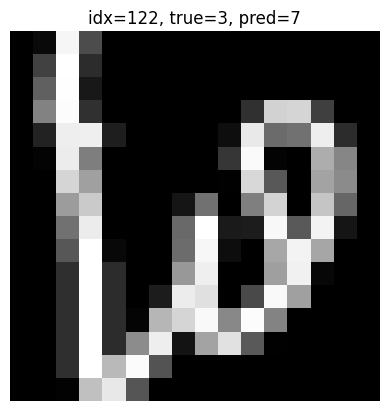

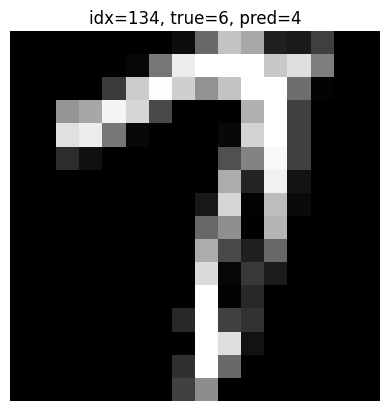

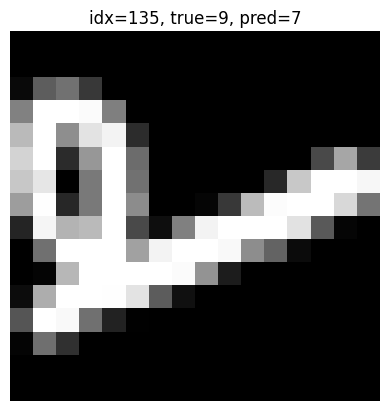

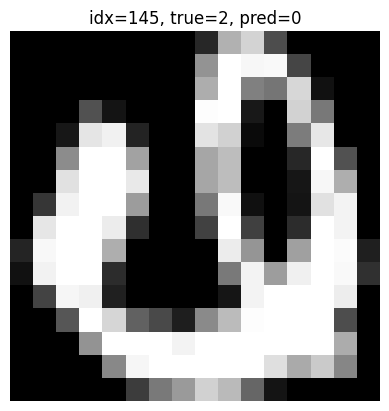

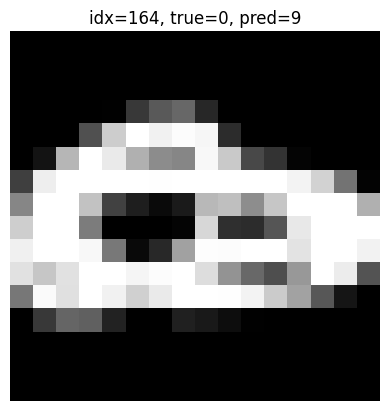

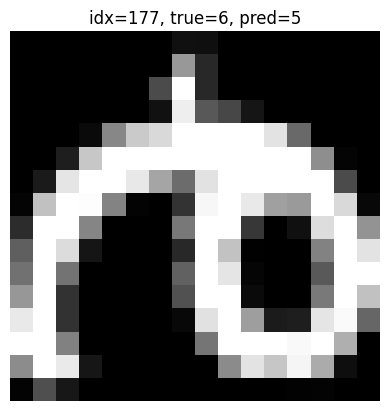

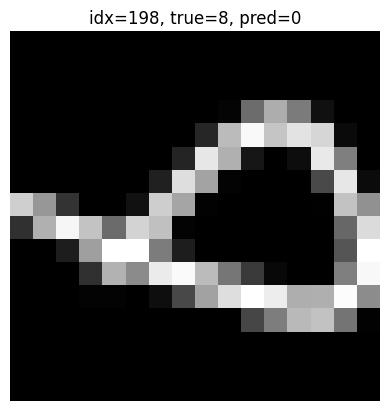

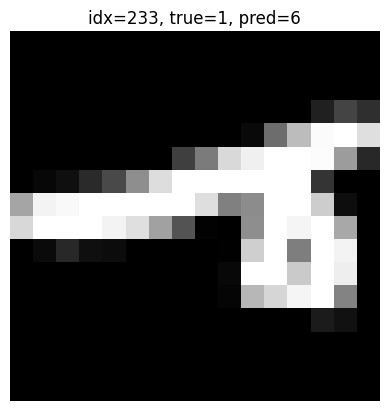

In [13]:
mis_idx = np.where(y_pred_linear != y_true)[0]

print("Number of misclassified digits:", len(mis_idx))

for idx in mis_idx[:12]:
    show_digit(
        A_test[:, idx],
        title=f"idx={idx}, true={int(y_true[idx])}, pred={int(y_pred_linear[idx])}"
    )

### Task 3

### Singular Value Analysis by Digit Class

In this step, we analyze the **singular values of each digit class separately** in order to understand how many SVD basis vectors are needed to represent each class accurately.

For every digit (0–9), we perform **SVD on the training samples belonging to that class**. The singular values indicate how much variance (or information) is captured by each basis vector. To quantify the effective dimensionality of each class, we compute the **minimum number of basis vectors (k)** required to capture a certain percentage of the total energy:

* **95% energy** → number of components needed for a compact representation
* **99% energy** → number of components needed for a near-complete representation



### Interpretation of the Results

The results show that **different digit classes require different numbers of basis vectors** to reach the same energy level.

* **Digit 1** requires very few components (only **2 for 95% energy**), which indicates that this digit has **very low structural variability**. This is expected because the digit “1” is visually simple and usually written in a similar way.
* More complex digits such as **2, 3, 5, and 8** require **many more components** (around **30–46 for 95% energy**), indicating higher variability in how they are written.
* For **99% energy**, the required dimensionality increases significantly (average ≈ **60 components**), which shows that capturing nearly all variations in handwriting requires many more basis vectors.

Overall, the results suggest that **some digits are intrinsically more complex than others**, and therefore using the **same number of basis vectors for all classes may not be optimal**. This motivates the next experiment, where we test whether using **different numbers of basis vectors for different digit classes** can improve classification performance.


In [14]:
print(" TASK 3:  SVD COMPONENT ANALYSIS")

print(" Singular Values Analysis by Digit Class")


def k_for_energy(svals, energy_threshold=0.95):
    """
    Find minimum k such that cumulative energy >= threshold
    """
    energy = np.cumsum(svals**2) / np.sum(svals**2)
    idx = np.where(energy >= energy_threshold)[0]
    return idx[0] + 1 if len(idx) > 0 else len(svals)

# Compute k for 95% and 99% energy 
print("\n Optimal k per digit based on cumulative singular value energy)")
print("-" * 70)
print(f"{'Digit':<8} {'SV(1)':<12} {'SV(2)':<12} {'SV(3)':<12} {'k(95%)':<10} {'k(99%)':<10}")
print("-" * 70)

k95_linear = {}
k99_linear = {}

for digit in range(10):
    svals = S_class[digit]
    k95 = k_for_energy(svals, 0.95)
    k99 = k_for_energy(svals, 0.99)
    
    k95_linear[digit] = k95
    k99_linear[digit] = k99
    
    print(f"{digit:<8} {svals[0]:<12.2f} {svals[1]:<12.2f} {svals[2]:<12.2f} {k95:<10} {k99:<10}")

print("-" * 70)

avg_k95_linear = np.mean(list(k95_linear.values()))
avg_k99_linear = np.mean(list(k99_linear.values()))


print(f"   Average k for 95% energy: {avg_k95_linear:.1f}")
print(f"   Average k for 99% energy: {avg_k99_linear:.1f}")

 TASK 3:  SVD COMPONENT ANALYSIS
 Singular Values Analysis by Digit Class

 Optimal k per digit based on cumulative singular value energy)
----------------------------------------------------------------------
Digit    SV(1)        SV(2)        SV(3)        k(95%)     k(99%)    
----------------------------------------------------------------------
0        184.45       97.59        62.05        30         84        
1        234.04       41.93        24.85        2          11        
2        138.28       57.40        46.40        46         94        
3        126.64       39.77        33.32        32         70        
4        123.03       41.63        34.93        30         63        
5        94.28        37.85        35.77        32         59        
6        141.96       52.19        37.97        24         57        
7        160.20       46.71        36.53        18         51        
8        133.07       41.64        34.46        33         70        
9        141.22    

### Normalized Singular Value Decay by Digit Class

In this plot we visualize how the **singular values decay for each digit class**.
For every digit (0–9), we plot the singular values obtained from the SVD of the corresponding training matrix. To make the curves comparable across classes, each sequence of singular values is **normalized by the first singular value**.

The x-axis represents the **index of the singular value**, while the y-axis shows the **normalized magnitude of the singular value**.

### Interpretation

The curves show how quickly the singular values decrease for each digit class. A **faster decay** indicates that most of the information of that class can be captured with only a few basis vectors. A **slower decay** means that more components are required to represent the variability of that digit.

From the plot we observe that:

* **Digit 1** exhibits a very steep decay, meaning that only a few basis vectors are sufficient to represent it. This reflects the fact that the digit "1" has a simple and consistent structure.
* Other digits such as **2, 3, 5, and 8** show a slower decay, indicating that they have **greater variability in handwriting** and therefore require more basis vectors.
* Overall, the decay patterns differ between classes, suggesting that **using the same number of basis vectors for all digits may not be optimal**.

This observation motivates the next experiment, where we test whether allowing **different numbers of basis vectors per class** can improve classification performance.


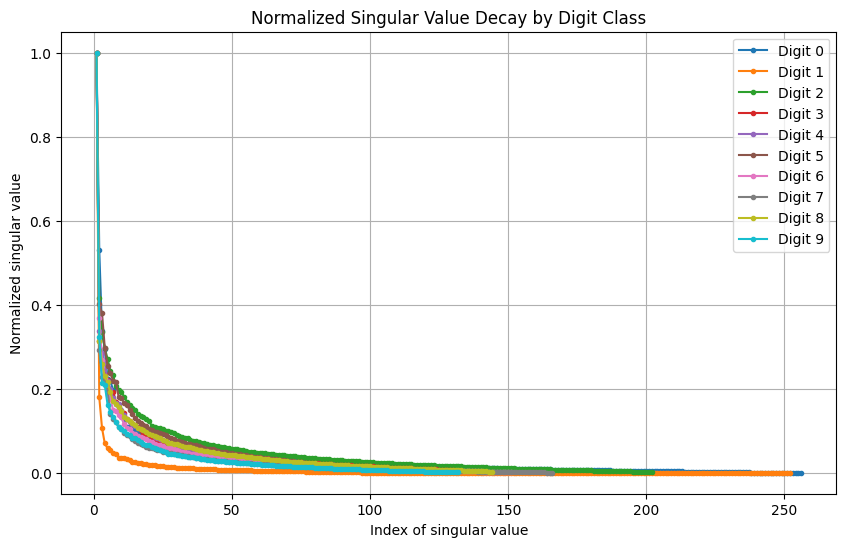

In [15]:
plt.figure(figsize=(10,6))

for digit in range(10):
    svals = S_class[digit]
    plt.plot(
        range(1, len(svals)+1),
        svals / svals[0],
        marker='o',
        markersize=3,
        label=f'Digit {digit}'
    )

plt.xlabel("Index of singular value")
plt.ylabel("Normalized singular value")
plt.title("Normalized Singular Value Decay by Digit Class")
plt.grid(True)
plt.legend()
plt.show()

### Determining the Number of Basis Vectors per Digit Class

Using the singular values computed for each digit class, we determine the **minimum number of basis vectors (k)** required to capture **95% of the total energy** of the class.



### Interpretation of the Results

The results show significant differences in the dimensionality required by each digit class.

* **Digit 1** requires only **2 basis vectors**, confirming that it has very low variability and a simple structure.
* Digits such as **2, 3, 5, and 8** require **many more basis vectors (around 30–46)**, indicating greater variability in how they are written.
* Other digits such as **7 and 9** require a moderate number of components.

These differences suggest that the **intrinsic dimensionality of each digit class varies**, which motivates testing whether using **different numbers of basis vectors for different classes** could improve classification performance.


In [16]:
k_per_class = {}

for digit in range(10):
    svals = S_class[digit]
    k_per_class[digit] = k_for_energy(svals, 0.95)

print("k per class (95% energy):")
for d in range(10):
    print(f"Digit {d}: k = {k_per_class[d]}")

k per class (95% energy):
Digit 0: k = 30
Digit 1: k = 2
Digit 2: k = 46
Digit 3: k = 32
Digit 4: k = 30
Digit 5: k = 32
Digit 6: k = 24
Digit 7: k = 18
Digit 8: k = 33
Digit 9: k = 18


### Classification with Class-Specific Number of Basis Vectors

To investigate whether using different numbers of basis vectors per class improves classification performance, we implement a modified classifier where each digit class uses its own dimensionality.

Instead of using the same number of SVD basis vectors for all digits, we use the values obtained from the **95% energy analysis**. For each digit (d), we keep the first (k_d) singular vectors of the corresponding class subspace.



We then compute the **relative reconstruction error**

The digit class that produces the **smallest reconstruction error** is selected as the predicted label.

This experiment allows us to evaluate whether adapting the dimensionality of each class according to its intrinsic complexity can improve classification accuracy compared to using a fixed number of basis vectors for all classes.


In [17]:
def classify_variable_k(x):
    # Calculate the norm of the input vector for relative error calculation
    x_norm = np.linalg.norm(x) + 1e-12
    
    best_digit = None
    best_score = np.inf # Start with infinity to find the minimum residual
    
    for digit in range(10):
        # Retrieve the custom k value for this specific digit (from 95% energy threshold)
        k = k_per_class[digit]
        # Extract only the first k singular vectors for the current digit class
        Uk = U_class[digit][:, :k]
        # Project the unknown image x onto the custom-sized subspace
        proj = Uk @ (Uk.T @ x)
        r = x - proj
        # Compute the relative residual score
        score = np.linalg.norm(r) / x_norm
        
        if score < best_score:
            best_score = score
            best_digit = digit
    
    return best_digit

### Computing Class-Specific SVD Bases

Before testing class-specific numbers of basis vectors, we compute a separate SVD for each digit class and store both the left singular vectors and the singular values.

For each digit \(d\), the columns of \(U_d\) form an orthonormal basis for the subspace of that class, while the singular values in \(S_d\) describe how the variance is distributed across the basis vectors.

These class-specific bases are required for the variable-\(k\) classifier, since each digit class may use a different number of retained singular vectors.

In [18]:
print("Computing class-specific SVD bases...")

U_class = {}
S_class = {}

for digit in range(10):
    idx = np.where(d_train == digit)[0]
    A_digit = A_train[:, idx]

    U_d, S_d, VT_d = np.linalg.svd(A_digit, full_matrices=False)

    U_class[digit] = U_d
    S_class[digit] = S_d

print("Stored U_class and S_class for all digit classes.")

Computing class-specific SVD bases...
Stored U_class and S_class for all digit classes.


### Classification Experiment with Variable Number of Basis Vectors

To evaluate whether using different numbers of basis vectors per class improves classification performance, we perform a classification experiment using the class-specific values (k_d) obtained from the 95% energy threshold.

For each digit class, we keep only the first (k_d) singular vectors of its corresponding SVD subspace. A test image is projected onto each class-specific subspace, and the relative reconstruction error is computed. The predicted label corresponds to the class with the smallest reconstruction error.

The resulting classification accuracy is **91.28%**, which is lower than the accuracy obtained using a fixed number of basis vectors for all classes (approximately **94.17%**).

This result indicates that although the intrinsic dimensionality of the digit classes differs, using different numbers of basis vectors per class does not necessarily improve classification performance. In practice, a common dimensionality for all classes may provide a better balance between representation and class separation.


In [19]:
# Initialize counter for correct predictions
correct = 0

# Loop through all images in the test set
for i in range(A_test.shape[1]):
    # Use the optimized variable-k function based on 95% energy
    pred = classify_variable_k(A_test[:, i])
    
    if pred == int(d_test[i]):
        correct += 1
# Calculate final accuracy percentage
acc_variable = correct / A_test.shape[1]

print("Accuracy with variable k per class:", acc_variable * 100)

Accuracy with variable k per class: 91.28051818634778


### Optional Task 1: Two-Stage Classification Function

### Baseline SVD Classification

Before implementing the two-stage algorithm, we first compute the baseline performance of the standard SVD classifier. Using the optimal number of basis vectors found in Task 1 ( (k = 18) ), we classify all test digits using the standard reconstruction-based SVD method.

This baseline accuracy provides a reference point for evaluating the two-stage algorithm. Later, we will compare the performance of the proposed faster variant with this baseline to determine whether similar accuracy can be achieved while reducing the computational cost during the test phase.


In [20]:

# Define acc_star (best k from TASK 1)


k_star = 18

y_true = d_test.astype(int)

# Classification with best k
y_pred = np.zeros_like(y_true)

for i in range(A_test.shape[1]):
    y_pred[i], _ = classify_digit(A_test[:, i], k_star)

acc_star = np.mean(y_pred == y_true)

print(f"Baseline accuracy (k={k_star}): {acc_star*100:.2f}%")

Baseline accuracy (k=18): 94.17%


### Two-Stage Classification with SVD

In order to reduce the computational cost during the testing phase, we implement a **two-stage SVD classification algorithm**.

#### Stage 1 (Fast Screening)

In the first stage, the unknown digit is compared with each digit class using **only the first singular vector** of that class. This provides a very fast approximation of the reconstruction error.

For each class we compute the **relative residual**


The algorithm then compares the **best and second-best residuals**. If the best residual is significantly smaller than the second one (controlled by a threshold), the digit is **classified immediately** using the result of Stage 1.

#### Stage 2 (Full SVD Classification)

If the decision from Stage 1 is not sufficiently clear, the algorithm proceeds to Stage 2. In this stage we apply the **full SVD classifier using (k = 18)** basis vectors, which was found to be optimal in Task 1.

This guarantees that the final classification decision is as reliable as the baseline method.

---

### Experimental Results

We tested several thresholds controlling how confident Stage 1 must be before skipping Stage 2.

| Threshold | Accuracy   | Stage 1 Only | Stage 2 Needed |
| --------- | ---------- | ------------ | -------------- |
| 1.2       | 93.97%     | 43.0%        | 57.0%          |
| **1.5**   | **94.17%** | **16.8%**    | **83.2%**      |
| 2.0       | 94.17%     | 10.0%        | 90.0%          |
| 3.0       | 94.17%     | 6.1%         | 93.9%          |

The best configuration is obtained with **threshold = 1.5**, which achieves:

* **Accuracy:** 94.17%
* **Same accuracy as the baseline SVD classifier**
* **Stage 2 avoided in 16.8% of the test samples**

---

### Conclusion

The two-stage approach demonstrates that a portion of the digits can be **confidently classified using only the first singular vector**, avoiding the expensive full SVD comparison.

Although the improvement in computational cost is moderate, the method shows that **early decision mechanisms can reduce test-time computations without sacrificing classification accuracy**.


In [21]:
print("OPTIONAL TASK 1: TWO-STAGE ALGORITHM WITH SVD")


def classify_two_stage(x, threshold=1.5):
    
    x_norm = np.linalg.norm(x) + 1e-12
    
    #  STAGE 1: Use only k=1 
    residuals_stage1 = {}
    
    for digit in range(10):
        Uk = U_class[digit][:, :1]   # only first singular vector
        proj = Uk @ (Uk.T @ x)
        r = x - proj
        score = np.linalg.norm(r) / x_norm
        residuals_stage1[digit] = score
    
    # Sort Stage 1 scores
    sorted_digits_s1 = sorted(residuals_stage1.items(), key=lambda x: x[1])
    
    best_digit_s1 = sorted_digits_s1[0][0]
    best_score_s1 = sorted_digits_s1[0][1]
    second_score_s1 = sorted_digits_s1[1][1]
    
    # Ratio test
    ratio = second_score_s1 / (best_score_s1 + 1e-10)
    
    if ratio > threshold:
        return best_digit_s1, 1
    
    #  STAGE 2: Use full k only on top candidates 
    residuals_stage2 = {}
    
    top_candidates = [d for d, _ in sorted_digits_s1[:3]]
    
    for digit in top_candidates:
        Uk = U_class[digit][:, :k_star]
        proj = Uk @ (Uk.T @ x)
        r = x - proj
        score = np.linalg.norm(r) / x_norm
        residuals_stage2[digit] = score
    
    best_digit_s2 = min(residuals_stage2, key=residuals_stage2.get)
    
    return best_digit_s2, 2


# Test with different thresholds
thresholds = [1.2, 1.5, 2.0, 3.0]

print("\nTesting different thresholds...\n")
print("-" * 80)
print(f"{'Threshold':<12} {'Accuracy (%)':<18} {'Stage 1 Only':<15} {'Stage 2 Needed':<15}")
print("-" * 80)

results_two_stage = {}

for threshold in thresholds:
    y_pred_2stage = np.zeros_like(y_true)
    stage1_count = 0
    stage2_count = 0
    
    for i in range(A_test.shape[1]):
        x = A_test[:, i]
        pred, stage = classify_two_stage(x, threshold=threshold)
        y_pred_2stage[i] = pred
        
        if stage == 1:
            stage1_count += 1
        else:
            stage2_count += 1
    
    accuracy = np.mean(y_pred_2stage == y_true)
    results_two_stage[threshold] = {
        'accuracy': accuracy,
        'stage1': stage1_count,
        'stage2': stage2_count
    }
    
    stage1_pct = 100 * stage1_count / A_test.shape[1]
    stage2_pct = 100 * stage2_count / A_test.shape[1]
    
    print(f"{threshold:<12} {accuracy*100:<18.2f} {stage1_pct:<14.1f}% {stage2_pct:<14.1f}%")

print("-" * 80)

# Find best threshold
best_threshold = max(results_two_stage, 
                     key=lambda t: results_two_stage[t]['accuracy'])
best_acc_2stage = results_two_stage[best_threshold]['accuracy']
best_stage1_pct = 100 * results_two_stage[best_threshold]['stage1'] / A_test.shape[1]

print(f"\n Results:")
print(f"   Best threshold: {best_threshold}")
print(f"   Best accuracy: {best_acc_2stage*100:.2f}%")
print(f"   Stage 1 only: {best_stage1_pct:.1f}%")
print(f"   Stage 2 needed: {100-best_stage1_pct:.1f}%")

# Compare with original
print(f"\n Comparison:")
print(f"   Original (k=18): {acc_star*100:.2f}%")
print(f"   Two-stage:       {best_acc_2stage*100:.2f}%")
if abs(best_acc_2stage - acc_star) < 0.01:
    print(f"    Same Accuracy")
    print(f"    Speedup: {best_stage1_pct:.1f}% of samples need only Stage 1")
else:
    loss = (acc_star - best_acc_2stage) * 100
    print(f"\n Comparison:")
    print(f"   Original (k=18): {acc_star*100:.2f}%")
    print(f"   Two-stage:       {best_acc_2stage*100:.2f}%")
    
    if abs(best_acc_2stage - acc_star) < 0.001:
        print("   Same Accuracy")
        print(f"   Speedup: {best_stage1_pct:.1f}% of samples need only Stage 1")
    else:
        print(f"   Accuracy loss: {loss:.2f}%")
    print(f"\n Answers to Questions:")
    print("    Is it possible to get as good results?")
    if abs(best_acc_2stage - acc_star) < 0.001:
        print(f"       Yes. Same accuracy ({best_acc_2stage*100:.2f}%)")
    else:
        print(f"       No. Loss of {loss:.2f}%")

    print(f"    How frequently is the second stage unnecessary?")
    print(f"       Stage 2 unnecessary in {best_stage1_pct:.1f}% of cases")
    print(f"       Stage 2 needed in {100-best_stage1_pct:.1f}% of cases")



OPTIONAL TASK 1: TWO-STAGE ALGORITHM WITH SVD

Testing different thresholds...

--------------------------------------------------------------------------------
Threshold    Accuracy (%)       Stage 1 Only    Stage 2 Needed 
--------------------------------------------------------------------------------
1.2          91.68              43.0          % 57.0          %
1.5          91.83              16.8          % 83.2          %
2.0          91.83              10.0          % 90.0          %
3.0          91.83              6.1           % 93.9          %
--------------------------------------------------------------------------------

 Results:
   Best threshold: 1.5
   Best accuracy: 91.83%
   Stage 1 only: 16.8%
   Stage 2 needed: 83.2%

 Comparison:
   Original (k=18): 94.17%
   Two-stage:       91.83%

 Comparison:
   Original (k=18): 94.17%
   Two-stage:       91.83%
   Accuracy loss: 2.34%

 Answers to Questions:
    Is it possible to get as good results?
       No. Loss of 2.34

### Rewrite show_digit for 20x20
This block implements the updated visualization function required by the prompt. Since the Tangent Distance method often involves augmenting images or working with higher-resolution grids (the prompt specifically mentions 20x20), this function replaces the previous $16 \times 16$ version.
It converts the 400-dimensional flattened vector back into its spatial $20 \times 20$ matrix form. Note the .T (transpose), which is crucial for maintaining the correct orientation if the data was originally stored in column-major order.
It shifts the values so the minimum is 0.
It scales the values to a range of $[0, 20]$ (a specific requirement mentioned in your earlier snippets). This ensures consistent contrast across different samples.



In [22]:
def show_digit_20x20(x, title=None):
    """
    Display a 20x20 digit image.
    Input: x is 400-dimensional vector (20x20 flattened)
    """
    a = x.reshape(20, 20).T
    a = a - np.min(a)
    if np.max(a) > 0:
        a = (20.0 / np.max(a)) * a
    plt.imshow(a, cmap="gray", interpolation="nearest")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

This function converts each handwritten digit from the original 16×16 pixel format (256 values) into a 20×20 pixel format (400 values).
1. Reshaping the vector into an image:
The input digit is originally stored as a 256-dimensional vector.
Using reshape(16,16), we convert it into a 16×16 image grid so that spatial operations can be applied.
Adding padding around the digit: 
2. We use np.pad() to add two pixels of zero padding on each side of the image.
This creates a 20×20 image. The padding provides extra space around the digit, which is important when applying small geometric transformations such as translations, rotations, or scaling.
3. Flattening the image back to a vector
Finally, the padded 20×20 image is flattened back into a 400-dimensional vector so that it can be processed by the rest of the algorithm.

By embedding the digit inside a larger 20×20 canvas, we allow these transformations to occur without immediately cutting off parts of the digit.


In [23]:
def embed_to_20x20(img_256):
    """
    Convert a 256-dim digit (16x16) into a 400-dim digit (20x20)
    by zero-padding with 2 pixels on each side.
    """
    img16 = img_256.reshape(16, 16).T
    img20 = np.pad(img16, ((2, 2), (2, 2)), mode='constant')
    return img20.T.flatten()

In this step we convert the entire dataset of digits from the original 16×16 representation (256 features) to the 20×20 representation (400 features) using the transformation defined in the previous block.

First, we create two empty matrices:

A_train_20 for the training digits

A_test_20 for the test digits

Each matrix has 400 rows, corresponding to the 400 pixels of a 20×20 image, and as many columns as there are samples in the dataset.
For each training sample A_train[:, i], we apply the function embed_to_20x20().

The resulting 400-dimensional vector is stored in the corresponding column of A_train_20.
The original dataset stores digits as 16×16 images, but the Tangent Distance method requires a 20×20 representation so that small geometric transformations (translation, rotation, scaling, etc.) can be modeled more effectively.

By converting every digit in the dataset to this new representation, we ensure that all subsequent computations (derivatives, tangent vectors, and distance calculations) operate in the same 400-dimensional space.



In [24]:
A_train_20 = np.zeros((400, A_train.shape[1]))
A_test_20  = np.zeros((400, A_test.shape[1]))

for i in range(A_train.shape[1]):
    A_train_20[:, i] = embed_to_20x20(A_train[:, i])

for i in range(A_test.shape[1]):
    A_test_20[:, i] = embed_to_20x20(A_test[:, i])

This function computes the horizontal and vertical derivatives of a digit image represented in the 20×20 format.

The input of the function is a 400-dimensional vector (img_400), which corresponds to a flattened 20×20 image. The function first reshapes this vector back into its 2D image form (20×20) so that spatial operations can be applied.
Next, two matrices are created:

dx for the x-derivative (horizontal change)

dy for the y-derivative (vertical change)
These derivatives are computed using a forward finite difference approximation:

The x-derivative measures how pixel intensity changes from a pixel to the one immediately to its right.

The y-derivative measures how pixel intensity changes from a pixel to the one immediately below it.

The derivatives describe how the image changes locally in space. These gradients are essential for building the tangent vectors that approximate small image transformations such as translations, rotations, and scaling.

In the Tangent Distance framework, these derivatives help define the local tangent space of each digit image.



In [25]:
def compute_derivatives(img_400):
    """
    Compute x- and y-derivatives of a 20x20 image using forward differences.
    Input: img_400 is a 400-dimensional vector
    Output: dx, dy are also 400-dimensional vectors
    """
    img = img_400.reshape(20, 20).T

    dx = np.zeros((20, 20))
    dy = np.zeros((20, 20))

    # x-derivative: right pixel minus current pixel
    dx[:, :-1] = img[:, 1:] - img[:, :-1]

    # y-derivative: lower pixel minus current pixel
    dy[:-1, :] = img[1:, :] - img[:-1, :]

    return dx.T.flatten(), dy.T.flatten()

In this step we compute the horizontal and vertical derivatives for every digit image in both the training and test datasets.

First, we create four matrices to store the derivative vectors:

DX_train → x-derivatives of the training images

DY_train → y-derivatives of the training images

DX_test → x-derivatives of the test images

DY_test → y-derivatives of the test images

Each matrix has 400 rows, corresponding to the 400 pixels of a 20×20 image, and one column for each sample in the dataset.

Next, we loop through every digit image:

For each training sample, we apply the compute_derivatives() function to calculate its horizontal (dx) and vertical (dy) gradients.

These derivative vectors are stored in the corresponding columns of DX_train and DY_train.

The same process is then repeated for the test dataset, filling the matrices DX_test and DY_test.

During the process, the code prints progress updates every 500 samples so that we can track the computation.

Finally, the shapes of all matrices are printed to verify that the dimensions are correct.

In [26]:
print("OPTIONAL TASK 2: TANGENT DISTANCE CLASSIFICATION")

# Compute derivatives for all training images
print("Computing derivatives for training images...")

DX_train = np.zeros((400, A_train_20.shape[1]))
DY_train = np.zeros((400, A_train_20.shape[1]))

for i in range(A_train_20.shape[1]):
    if (i + 1) % 500 == 0:
        print(f"  Processed {i+1}/{A_train_20.shape[1]} training samples")

    dx, dy = compute_derivatives(A_train_20[:, i])
    DX_train[:, i] = dx
    DY_train[:, i] = dy

print(f"Derivatives computed for {A_train_20.shape[1]} training samples")

# Compute derivatives for all test images
print("Computing derivatives for test images...")

DX_test = np.zeros((400, A_test_20.shape[1]))
DY_test = np.zeros((400, A_test_20.shape[1]))

for i in range(A_test_20.shape[1]):
    if (i + 1) % 500 == 0:
        print(f"  Processed {i+1}/{A_test_20.shape[1]} test samples")

    dx, dy = compute_derivatives(A_test_20[:, i])
    DX_test[:, i] = dx
    DY_test[:, i] = dy

print(f"Derivatives computed for {A_test_20.shape[1]} test samples")

print("\nDerivative shapes:")
print(f"  A_train_20: {A_train_20.shape}")
print(f"  A_test_20:  {A_test_20.shape}")
print(f"  DX_train:   {DX_train.shape}")
print(f"  DY_train:   {DY_train.shape}")
print(f"  DX_test:    {DX_test.shape}")
print(f"  DY_test:    {DY_test.shape}")

OPTIONAL TASK 2: TANGENT DISTANCE CLASSIFICATION
Computing derivatives for training images...
  Processed 500/1707 training samples
  Processed 1000/1707 training samples
  Processed 1500/1707 training samples
Derivatives computed for 1707 training samples
Computing derivatives for test images...
  Processed 500/2007 test samples
  Processed 1000/2007 test samples
  Processed 1500/2007 test samples
  Processed 2000/2007 test samples
Derivatives computed for 2007 test samples

Derivative shapes:
  A_train_20: (400, 1707)
  A_test_20:  (400, 2007)
  DX_train:   (400, 1707)
  DY_train:   (400, 1707)
  DX_test:    (400, 2007)
  DY_test:    (400, 2007)


### Build Tangent Vectors

This function constructs the tangent matrix for a single digit image.
The tangent matrix describes how the image changes under small geometric transformations, which is the core idea behind the Tangent Distance method.

The function receives three inputs:

img_400 → the digit image represented as a 400-dimensional vector (20×20 image)

dx_400 → the horizontal derivative of the image

dy_400 → the vertical derivative of the image

First, the vectors are reshaped back into 20×20 image form so that spatial operations can be performed.

Next, coordinate grids (x_coords and y_coords) are created.
These grids represent the pixel positions in the image and are used to model how the image changes under different transformations.

Using the image derivatives and the coordinate grids, the code constructs seven tangent vectors, each corresponding to a small transformation of the digit:

1.Horizontal translation (t_x) – shift of the digit along the x-direction

2. Vertical translation (t_y) – shift of the digit along the y-direction

3. Rotation (t_rot) – small rotation around the center of the image

4. Scaling (t_scale) – small change in the size of the digit

5. Parallel deformation (t_par) – horizontal shear-like deformation

6. Diagonal deformation (t_diag) – diagonal shear transformation

7. Thickness variation (t_thick) – local changes in stroke thickness

Each of these transformations is represented as a 400-dimensional vector.

In [27]:
def build_tangent_matrix(img_400, dx_400, dy_400):
    """
    Build the 7 tangent vectors for one 20x20 digit.
    Returns a matrix of shape (400, 7).
    """
    # reshape to 20x20 image form
    img = img_400.reshape(20, 20).T
    dx = dx_400.reshape(20, 20).T
    dy = dy_400.reshape(20, 20).T

    # coordinate grids
    x_coords, y_coords = np.meshgrid(np.arange(20), np.arange(20))

    # 7 tangent transformations
    t_x = dx
    t_y = dy
    t_rot = y_coords * dx - x_coords * dy
    t_scale = x_coords * dx + y_coords * dy
    t_par = x_coords * dx - y_coords * dy
    t_diag = y_coords * dx + x_coords * dy
    t_thick = np.sqrt(dx**2 + dy**2)

    # stack as columns -> shape (400, 7)
    T = np.column_stack([
        t_x.T.flatten(),
        t_y.T.flatten(),
        t_rot.T.flatten(),
        t_scale.T.flatten(),
        t_par.T.flatten(),
        t_diag.T.flatten(),
        t_thick.T.flatten()
    ])

    return T

### Tangent Distance Classification
n this step we generate the tangent matrices for every image in both the training and test datasets.

Each digit image has its own local tangent space, which describes how the image can change under small transformations such as translation, rotation, or scaling. The function build_tangent_matrix() (from the previous block) computes these transformation vectors for a single image.

Here, we apply that function to all images in the dataset.

First, we create an empty list called T_train.
We then loop through all training samples and for each digit we compute its tangent matrix using:

the 20×20 digit representation (A_train_20[:, i])

the horizontal derivatives (DX_train[:, i])

the vertical derivatives (DY_train[:, i])

Each resulting tangent matrix has shape (400 × 7) and is appended to the list T_train.

The same procedure is repeated for the test dataset, creating the list T_test.

The reason we compute tangent matrices for both datasets is that we will use Double-Sided Tangent Distance, where both the training digit and the test digit are allowed to move within their respective tangent spaces.
Finally, the code prints:
 1. the number of tangent matrices created for the training and test sets

 2.the shape of one example tangent matrix to confirm that it has the expected dimensions.


In [28]:
print("Building tangent matrices for training and test samples...")

# Generate the 7 tangent vectors for every training sample
T_train = []
for i in range(A_train_20.shape[1]):
    T_train.append(build_tangent_matrix(A_train_20[:, i], DX_train[:, i], DY_train[:, i]))

# Generate the 7 tangent vectors for every test sample
# This allows double-sided tangent distance
T_test = []
for i in range(A_test_20.shape[1]):
    T_test.append(build_tangent_matrix(A_test_20[:, i], DX_test[:, i], DY_test[:, i]))

print(f"Built {len(T_train)} training tangent matrices and {len(T_test)} test tangent matrices.")
print("Each tangent matrix has shape:", T_train[0].shape)

Building tangent matrices for training and test samples...
Built 1707 training tangent matrices and 2007 test tangent matrices.
Each tangent matrix has shape: (400, 7)


### Computing the Tangent Distance Between Two Digits
This function computes the tangent distance between one test digit and one training digit.

In a normal nearest-neighbor approach, we would simply compare the two images directly using their raw pixel values. However, this can be too strict, because two images of the same digit may differ slightly due to small shifts, rotations, scaling, or handwriting variations.

To handle this, the Tangent Distance method allows both images to move slightly inside their own local tangent spaces.

The inputs are:

p → the test digit as a 400-dimensional vector

e → the training digit as a 400-dimensional vector

Tp → the tangent matrix of the test digit, with shape (400, 7)

Te → the tangent matrix of the training digit, with shape (400, 7)

First, the code computes the raw difference between the two images: b = p - e
This is the initial pixel-wise difference before allowing any transformations.
Then, the code builds a combined matrix: A=[-Tp, Te], this matrix contains the tangent directions of both images.
The minus sign in front of Tp appears because we want to model the difference between the two locally transformed images.


Finally, the residual vector is computed: r=b-Aa and the tangent distance is defined as the Euclidean norm of this residual: ||r||.

In [29]:
# Tangent distance between two samples

def tangent_distance(p, Tp, e, Te):
    """
    Compute tangent distance between test sample p and training sample e.
    p, e: vectors of shape (400,)
    Tp, Te: tangent matrices of shape (400, 7)
    """
    # Calculate the initial distance vector between the two raw images
    b = p - e
    # We use -Tp because we want the difference between the two planes: (e + Te*a_e) - (p + Tp*a_p)
    A = np.hstack([-Tp, Te])   # shape (400, 14)

    # least squares residual
    alpha, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    # Calculate the remaining distance after applying the optimal transformations
    r = b - A @ alpha
    return np.linalg.norm(r)

### Tangent Distance Classification
This block performs the final digit classification using the Tangent Distance method.

The goal is simple: for each test digit, we compare it with all training digits and assign it the label of the closest one.

The code starts by creating an array called y_pred_tangent, which will store the predicted class for every test sample.

Then the classification process begins:

1. Loop over all test digits

For each test sample:

p is the current test image in 20×20 format

Tp is the corresponding tangent matrix of that test image

This gives us both the digit itself and the local transformation space around it.

2. Compare with all training digits

For each test digit, the code checks every training digit one by one:

e is the current training image

Te is its corresponding tangent matrix

The function tangent_distance(p, Tp, e, Te) is then used to compute how close the two digits are after allowing small geometric transformations.


3. Find the nearest neighbor

The code keeps track of:

best_dist → the smallest tangent distance found so far

best_digit → the label of the training digit that produced that smallest distance

At the end of the inner loop, the test digit is assigned the label of the closest training sample.

This is essentially a 1-nearest-neighbor classifier, but using tangent distance instead of ordinary Euclidean distance.

4. Compute final accuracy

After all test digits are classified, the code compares the predicted labels y_pred_tangent with the true labels d_test.

It then reports:

1.the overall accuracy

2.the number of correct classifications

3.the number of misclassified samples

4.the performance of the SVD baseline for comparison

In [30]:
# Tangent distance classification

print("Running tangent distance classification...")

# Initialize predictions array
y_pred_tangent = np.zeros_like(d_test, dtype=int)

# Outer loop: iterate through every test sample
for test_idx in range(A_test_20.shape[1]):
    if (test_idx + 1) % 100 == 0:
        print(f"  Processed {test_idx+1}/{A_test_20.shape[1]} test samples")

    p = A_test_20[:, test_idx]
    Tp = T_test[test_idx]

    best_dist = np.inf
    best_digit = None

    # Inner loop: compare against every training sample
    for train_idx in range(A_train_20.shape[1]):
        e = A_train_20[:, train_idx]
        Te = T_train[train_idx]

        dist = tangent_distance(p, Tp, e, Te)

        if dist < best_dist:
            best_dist = dist
            best_digit = int(d_train[train_idx])

    y_pred_tangent[test_idx] = best_digit

# Final accuracy
accuracy_tangent = np.mean(y_pred_tangent == d_test)

print("\nTangent Distance Results")
print(f"Accuracy: {accuracy_tangent*100:.2f}%")
print(f"Correct: {np.sum(y_pred_tangent == d_test)}/{len(d_test)}")
print(f"Misclassified: {np.sum(y_pred_tangent != d_test)}/{len(d_test)}")
print(f"SVD baseline (k=18): {acc_star*100:.2f}%")

Running tangent distance classification...
  Processed 100/2007 test samples
  Processed 200/2007 test samples
  Processed 300/2007 test samples
  Processed 400/2007 test samples
  Processed 500/2007 test samples
  Processed 600/2007 test samples
  Processed 700/2007 test samples
  Processed 800/2007 test samples
  Processed 900/2007 test samples
  Processed 1000/2007 test samples
  Processed 1100/2007 test samples
  Processed 1200/2007 test samples
  Processed 1300/2007 test samples
  Processed 1400/2007 test samples
  Processed 1500/2007 test samples
  Processed 1600/2007 test samples
  Processed 1700/2007 test samples
  Processed 1800/2007 test samples
  Processed 1900/2007 test samples
  Processed 2000/2007 test samples

Tangent Distance Results
Accuracy: 92.43%
Correct: 1855/2007
Misclassified: 152/2007
SVD baseline (k=18): 94.17%


### Tangent Distance vs SVD Baseline

The Tangent Distance classifier achieved an **accuracy of 92.43%**, correctly classifying **1855 out of 2007** test digits, while **152 samples were misclassified**.

Tangent Distance is designed to account for **small geometric transformations** such as translation, rotation, scaling, and small deformations. By incorporating tangent vectors derived from image derivatives, the method attempts to model variations in handwritten digits more flexibly than simple pixel-based comparisons.

However, when compared with the **SVD-based classifier**, the results show that the SVD approach performed better in this experiment:

* **Tangent Distance:** 92.43%
* **SVD baseline (k = 18):** 94.17%

Thus, the Tangent Distance classifier did **not outperform the SVD-based method** on this dataset.

One possible explanation is that the **SVD subspace representation captures the dominant structural patterns of each digit class very effectively**, providing a robust low-dimensional representation for classification. In contrast, the performance of Tangent Distance may depend more heavily on the **accuracy of the derivative approximations and the construction of the tangent vectors**.

Overall, while Tangent Distance provides an interesting transformation-invariant approach to digit recognition, in this implementation the **SVD classifier achieved higher accuracy and remained the best-performing method**.
